![](https://www.soyhenry.com/_next/static/media/HenryLogo.bb57fd6f.svg)

# Clase 06: NLP con atencion usando Las mil y una noches

profesor [Carlos Daniel Jiménez](danieljimenez88m@gmail.com)


En NLP, resumir una secuencia larga en un unico vector suele ser un cuello de botella. La atencion aparece para relajar ese problema: en lugar de confiar en un resumen fijo, el modelo aprende a mirar que partes del contexto son mas utiles para la tarea.


In [1]:
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader, Dataset


from tools.notebook_utils import choose_value, configure_runtime
from tools.text_corpus import build_vocabulary, chunk_text, corpus_stats, load_corpus_text, simple_tokenize

runtime = configure_runtime(seed=31)
print(runtime.summary())
print(corpus_stats())
        


seed=31 | smoke=False | online_mode=False | device=mps
{'documents': 6, 'characters': 13075, 'tokens': 2508, 'chunks': 41, 'unique_tokens': 926}


## Por que existe la atencion

Una arquitectura encoder-decoder clasica intenta comprimir toda la entrada en un solo estado. Eso es costoso cuando el texto es largo, variado y contiene nombres, objetos y relaciones que reaparecen despues de muchas palabras.

La atencion existe para responder una pregunta puntual:

> si debo decidir algo ahora, sobre que partes del contexto me conviene apoyar la decision.

En esta notebook usamos ventanas largas del corpus para una tarea simple de clasificacion tematica. Las etiquetas se construyen con reglas debiles para que el foco este en el mecanismo, no en una annotation manual extensa.


In [2]:
label_rules = {
    'corte': {'rey', 'palacio', 'visir', 'princesa', 'reina', 'trono'},
    'viaje': {'mar', 'isla', 'barco', 'mercader', 'nave', 'viaje'},
    'magia': {'genio', 'ifrit', 'jarra', 'anillo', 'espiritu', 'hechizo'},
}

raw_chunks = chunk_text(load_corpus_text(), chunk_size=55, overlap=20)
examples = []
for chunk in raw_chunks:
    tokens = simple_tokenize(chunk)
    scores = {label: sum(token in keywords for token in tokens) for label, keywords in label_rules.items()}
    label = max(scores, key=scores.get)
    if scores[label] >= 2:
        examples.append((tokens, label, chunk))

label_counts = Counter(label for _, label, _ in examples)
print({'usable_examples': len(examples), 'label_counts': dict(label_counts)})

label_to_id = {label: index for index, label in enumerate(sorted(label_rules))}
id_to_label = {index: label for label, index in label_to_id.items()}

train_examples, test_examples = train_test_split(
    examples,
    test_size=0.25,
    random_state=31,
    stratify=[label for _, label, _ in examples],
)
train_examples, val_examples = train_test_split(
    train_examples,
    test_size=0.25,
    random_state=31,
    stratify=[label for _, label, _ in train_examples],
)

train_tokens = [token for tokens, _, _ in train_examples for token in tokens]
vocab = build_vocabulary(train_tokens, min_freq=1)
print({'vocab_size': len(vocab.itos)})
        


{'usable_examples': 22, 'label_counts': {'corte': 10, 'viaje': 7, 'magia': 5}}
{'vocab_size': 298}


In [3]:
class AttentionDataset(Dataset):
    def __init__(self, items: list[tuple[list[str], str, str]]) -> None:
        self.items = items

    def __len__(self) -> int:
        return len(self.items)

    def __getitem__(self, index: int) -> tuple[torch.Tensor, int, str]:
        tokens, label, chunk = self.items[index]
        encoded = torch.tensor(vocab.encode(tokens), dtype=torch.long)
        return encoded, label_to_id[label], chunk


def collate_batch(batch):
    sequences, labels, raw_text = zip(*batch)
    lengths = torch.tensor([len(sequence) for sequence in sequences], dtype=torch.long)
    padded = pad_sequence(sequences, batch_first=True, padding_value=vocab.stoi['<pad>'])
    labels = torch.tensor(labels, dtype=torch.long)
    return padded, lengths, labels, list(raw_text)


train_loader = DataLoader(AttentionDataset(train_examples), batch_size=int(choose_value(16, 8)), shuffle=True, collate_fn=collate_batch)
val_loader = DataLoader(AttentionDataset(val_examples), batch_size=16, collate_fn=collate_batch)
test_loader = DataLoader(AttentionDataset(test_examples), batch_size=16, collate_fn=collate_batch)


class AdditiveAttention(torch.nn.Module):
    def __init__(self, hidden_dim: int) -> None:
        super().__init__()
        self.query_layer = torch.nn.Linear(hidden_dim, hidden_dim)
        self.key_layer = torch.nn.Linear(hidden_dim, hidden_dim)
        self.score_layer = torch.nn.Linear(hidden_dim, 1)

    def forward(self, hidden_states: torch.Tensor, mask: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        query = hidden_states.mean(dim=1, keepdim=True)
        energy = torch.tanh(self.query_layer(query) + self.key_layer(hidden_states))
        scores = self.score_layer(energy).squeeze(-1)
        scores = scores.masked_fill(~mask, -1e9)
        weights = torch.softmax(scores, dim=1)
        context = torch.bmm(weights.unsqueeze(1), hidden_states).squeeze(1)
        return context, weights


class AttentionClassifier(torch.nn.Module):
    def __init__(self, vocab_size: int, embedding_dim: int = 48, hidden_dim: int = 64) -> None:
        super().__init__()
        self.embedding = torch.nn.Embedding(vocab_size, embedding_dim, padding_idx=vocab.stoi['<pad>'])
        self.encoder = torch.nn.GRU(embedding_dim, hidden_dim // 2, batch_first=True, bidirectional=True)
        self.attention = AdditiveAttention(hidden_dim)
        self.classifier = torch.nn.Linear(hidden_dim, len(label_to_id))

    def forward(self, input_ids: torch.Tensor, lengths: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        embedded = self.embedding(input_ids)
        hidden_states, _ = self.encoder(embedded)
        mask = input_ids.ne(vocab.stoi['<pad>'])
        context, weights = self.attention(hidden_states, mask)
        logits = self.classifier(context)
        return logits, hidden_states, weights


model = AttentionClassifier(vocab_size=len(vocab.itos)).to(runtime.device)
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.005, weight_decay=1e-3)
        


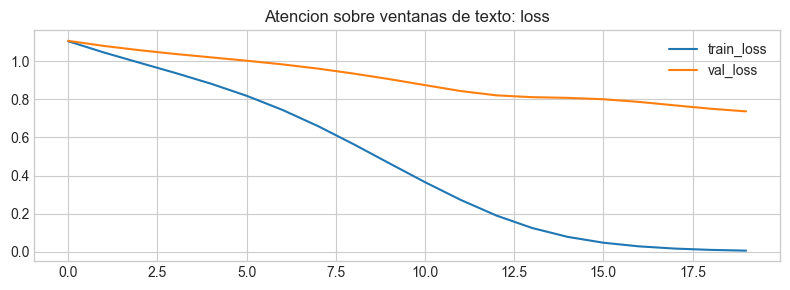

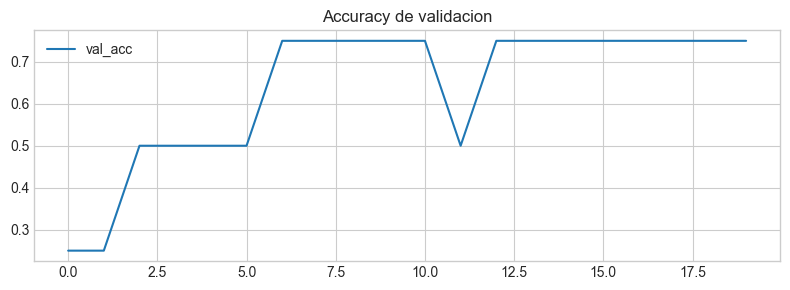

In [4]:
history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
epochs = int(choose_value(20, 8))

for epoch in range(epochs):
    model.train()
    train_loss_total = 0.0
    for input_ids, lengths, labels, _ in train_loader:
        input_ids = input_ids.to(runtime.device)
        lengths = lengths.to(runtime.device)
        labels = labels.to(runtime.device)

        optimizer.zero_grad()
        logits, _, _ = model(input_ids, lengths)
        loss = loss_fn(logits, labels)
        loss.backward()
        optimizer.step()
        train_loss_total += loss.item() * len(input_ids)

    model.eval()
    val_loss_total = 0.0
    predictions = []
    targets = []
    with torch.inference_mode():
        for input_ids, lengths, labels, _ in val_loader:
            input_ids = input_ids.to(runtime.device)
            lengths = lengths.to(runtime.device)
            labels = labels.to(runtime.device)
            logits, _, _ = model(input_ids, lengths)
            val_loss_total += loss_fn(logits, labels).item() * len(input_ids)
            predictions.extend(logits.argmax(dim=1).cpu().tolist())
            targets.extend(labels.cpu().tolist())

    history['train_loss'].append(train_loss_total / len(train_loader.dataset))
    history['val_loss'].append(val_loss_total / len(val_loader.dataset))
    history['val_acc'].append(accuracy_score(targets, predictions))

plt.figure(figsize=(8, 3))
plt.plot(history['train_loss'], label='train_loss')
plt.plot(history['val_loss'], label='val_loss')
plt.title('Atencion sobre ventanas de texto: loss')
plt.legend()
plt.tight_layout()

plt.figure(figsize=(8, 3))
plt.plot(history['val_acc'], label='val_acc')
plt.title('Accuracy de validacion')
plt.legend()
plt.tight_layout()
        


{'test_acc': 0.667}
Texto de ejemplo:
pero atribuyo aquella sensacion al sol del mediodia . de pronto la isla empezo a estremecerse . el agua alrededor se levanto en anillos oscuros y el capitan grito desde la nave que todos debian regresar a bordo . aquello no era una isla , sino el lomo de un pez gigantesco que dormia sobre ...
{'etiqueta_real': 'viaje', 'etiqueta_predicha': 'corte'}
Top tokens por atencion aditiva y dot-product:
{'token': 'del', 'additive': 0.668, 'dot': 0.001}
{'token': 'de', 'additive': 0.109, 'dot': 0.017}
{'token': 'dormia', 'additive': 0.037, 'dot': 0.001}
{'token': 'de', 'additive': 0.033, 'dot': 0.002}
{'token': 'sobre', 'additive': 0.027, 'dot': 0.002}
{'token': 'al', 'additive': 0.017, 'dot': 0.01}
{'token': 'una', 'additive': 0.016, 'dot': 0.001}
{'token': 'pez', 'additive': 0.011, 'dot': 0.002}
{'token': 'que', 'additive': 0.011, 'dot': 0.002}
{'token': 'gigantesco', 'additive': 0.01, 'dot': 0.004}


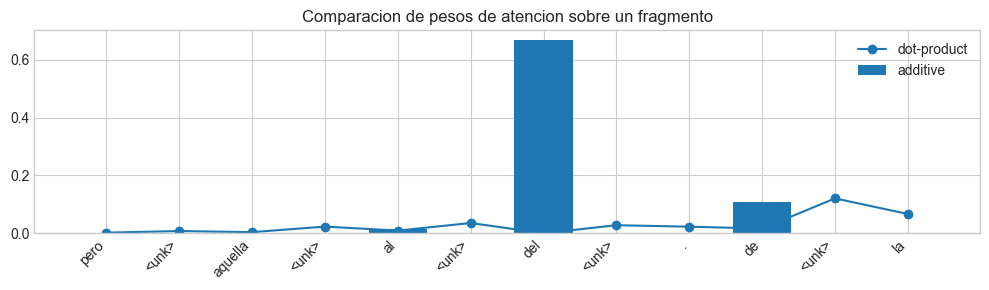

In [9]:
model.eval()
test_predictions = []
test_targets = []
first_batch = None
with torch.inference_mode():
    for batch in test_loader:
        if first_batch is None:
            first_batch = batch
        input_ids, lengths, labels, _ = batch
        logits, _, _ = model(input_ids.to(runtime.device), lengths.to(runtime.device))
        test_predictions.extend(logits.argmax(dim=1).cpu().tolist())
        test_targets.extend(labels.tolist())

print({'test_acc': round(accuracy_score(test_targets, test_predictions), 3)})

input_ids, lengths, labels, raw_text = first_batch
with torch.inference_mode():
    logits, hidden_states, additive_weights = model(input_ids.to(runtime.device), lengths.to(runtime.device))

sample_index = 0
sample_ids = input_ids[sample_index]
valid_mask = sample_ids.ne(vocab.stoi['<pad>'])
sample_tokens = vocab.decode(sample_ids[valid_mask].tolist())
query_vector = hidden_states[sample_index, valid_mask.to(runtime.device)].mean(dim=0)
dot_scores = torch.matmul(hidden_states[sample_index, valid_mask.to(runtime.device)], query_vector)
dot_weights = torch.softmax(dot_scores, dim=0).cpu()
additive = additive_weights[sample_index, valid_mask.to(runtime.device)].cpu()

ranking = sorted(
    zip(sample_tokens, additive.tolist(), dot_weights.tolist()),
    key=lambda item: item[1],
    reverse=True,
)[:10]

print('Texto de ejemplo:')
print(raw_text[sample_index][:600], '...')
print({'etiqueta_real': id_to_label[int(labels[sample_index])], 'etiqueta_predicha': id_to_label[int(logits[sample_index].argmax().cpu())]})
print('Top tokens por atencion aditiva y dot-product:')
for token, add_score, dot_score in ranking:
    print({'token': token, 'additive': round(add_score, 3), 'dot': round(dot_score, 3)})

plt.figure(figsize=(10, 3))
plt.bar(range(len(additive[:12])), additive[:12].tolist(), label='additive')
plt.plot(range(len(dot_weights[:12])), dot_weights[:12].tolist(), marker='o', label='dot-product')
plt.xticks(range(len(sample_tokens[:12])), sample_tokens[:12], rotation=45, ha='right')
plt.title('Comparacion de pesos de atencion sobre un fragmento')
plt.legend()
plt.tight_layout()
        


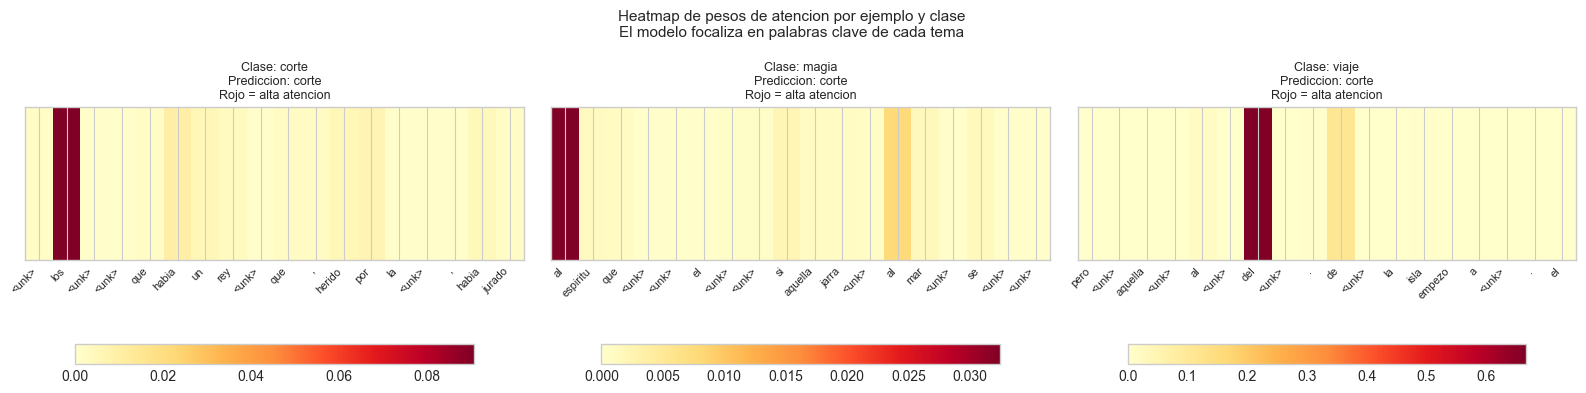

In [10]:
# Heatmap de atencion: visualizar en que tokens focaliza el modelo
import matplotlib.pyplot as plt
import numpy as np

model.eval()

# Recopilar un ejemplo por clase del test set
class_examples = {}
for batch in test_loader:
    input_ids_b, lengths_b, labels_b, raw_b = batch
    for i in range(len(labels_b)):
        lbl = id_to_label[int(labels_b[i])]
        if lbl not in class_examples:
            class_examples[lbl] = (
                input_ids_b[i:i+1],
                lengths_b[i:i+1],
                labels_b[i:i+1],
                raw_b[i],
            )
    if len(class_examples) == 3:
        break

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
MAX_TOKENS_SHOW = 18

for ax, lbl in zip(axes, sorted(class_examples)):
    ids, lens, labs, raw = class_examples[lbl]
    with torch.inference_mode():
        logits_ex, _, attn_weights = model(ids.to(runtime.device), lens.to(runtime.device))

    pred_lbl = id_to_label[int(logits_ex[0].argmax())]
    valid_mask = ids[0].ne(vocab.stoi['<pad>'])
    tokens = vocab.decode(ids[0][valid_mask].tolist())
    weights = attn_weights[0, valid_mask.to(runtime.device)].cpu().numpy()

    # Recortar a MAX_TOKENS_SHOW para que la visualizacion sea legible
    n = min(MAX_TOKENS_SHOW, len(tokens))
    tokens_show = tokens[:n]
    weights_show = weights[:n]

    # Heatmap horizontal: 1 fila x n columnas
    hm = ax.imshow(weights_show[np.newaxis, :], cmap='YlOrRd',
                   aspect='auto', vmin=0)
    ax.set_xticks(range(n))
    ax.set_xticklabels(tokens_show, rotation=45, ha='right', fontsize=8)
    ax.set_yticks([])
    ax.set_title(
        f'Clase: {lbl}\nPrediccion: {pred_lbl}\n'
        f'Rojo = alta atencion',
        fontsize=9
    )
    plt.colorbar(hm, ax=ax, orientation='horizontal', pad=0.3, shrink=0.8)

plt.suptitle(
    'Heatmap de pesos de atencion por ejemplo y clase\n'
    'El modelo focaliza en palabras clave de cada tema',
    fontsize=11
)
plt.tight_layout()
# Esto explica POR QUE llamamos a esto "mecanismo de atencion":
# el modelo asigna pesos distintos a cada token segun su relevancia para la tarea


## Para cerrar

### Lo importante

- la atencion no reemplaza toda la arquitectura, pero cambia como se usa el contexto,
- una ventana larga no sirve de nada si el modelo no puede focalizar,
- los pesos de atencion no son una prueba causal, pero si una pista util para inspeccionar el comportamiento del modelo.

### Ejercicios sugeridos

- cambia las reglas de etiquetas y mira como cambia la interpretacion,
- aumenta `chunk_size` y observa si la atencion se vuelve mas selectiva,
- reemplaza la GRU por una BiLSTM y compara costo y accuracy.
